# 07F — Physiological Validity Filter

This notebook analyses the 10,000 conditional-sampling simulations and checks whether the generated patients/simulations are physiologically realistic enough for training tree-search algorithms and neural networks.

It creates:
- a full rule-by-rule validity table
- a valid successful dataset
- an invalid dataset with reasons
- rule failure summaries
- patient-level validity summaries
- diagnostic plots

Important: failed simulations are automatically excluded from the final ML-valid dataset, but they are kept in the diagnostics.

## Implemented physiological laws

Implemented rules:

1. `LVSV` and `RVSV` difference `< 1 ml`
2. `LASV` and `RASV` difference `< 1 ml` if atrial stroke-volume columns exist
3. `LASV` and `RASV` same order of magnitude if atrial columns exist
4. `ASV <= VSV / 3` for left and right sides if atrial columns exist
5. Pressure relation between pulmonary artery and left atrium  
   - Default implementation: `mPAP > LAP`, because pressure should drop from pulmonary artery to left atrium.
   - If you intentionally want the opposite rule `LAP > mPAP`, change `PULMONARY_PRESSURE_RULE`.
6. `SAP > CVP`
7. `CVP = RAP` within tolerance, because no vena cava model
8. `abs(SAP - DAP) > 30 mmHg`
9. `abs(sPAP - dPAP) > 15 mmHg`
10. Optional input-vs-output percent difference checks, disabled by default for now

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

# ============================================================
# PATH CONFIG
# ============================================================

cwd = Path.cwd()

# Works if notebook is run from project root or from 07_Conditional_Sampling_Strategy
if cwd.name == "07_Conditional_Sampling_Strategy":
    ROOT = cwd.parent
else:
    ROOT = cwd

CAMPAIGN_NAME = "conditional_sampling_100_patients_100_variations_v1"

RESULTS_DIR = (
    ROOT
    / "01_Data"
    / "Conditional_Sampling"
    / "simulation_results"
    / CAMPAIGN_NAME
)

FULL_DATASET_PATH = RESULTS_DIR / f"{CAMPAIGN_NAME}_FULL_DATASET.csv"

ANALYSIS_DIR = RESULTS_DIR / "analysis_07F_physiological_validity"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", cwd)
print("Project root:", ROOT)
print("Full dataset path:", FULL_DATASET_PATH)
print("Dataset exists:", FULL_DATASET_PATH.exists())
print("Analysis output dir:", ANALYSIS_DIR)

Current working directory: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\07_Conditional_Sampling_Strategy
Project root: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project
Full dataset path: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\conditional_sampling_100_patients_100_variations_v1_FULL_DATASET.csv
Dataset exists: True
Analysis output dir: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity


In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(FULL_DATASET_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

if "simulation_status" in df.columns:
    print("\nSimulation status counts:")
    display(df["simulation_status"].value_counts(dropna=False))
else:
    raise KeyError("Expected column simulation_status was not found.")

Dataset shape: (10000, 55)


,simulation_id,patient_id,variation_id,campaign_name,sampling_method,random_seed,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA,k_Vtot,k_Vsys,k_Vusv_sys,k_Vusv_sys_ven,k_Vusv_pulm_ven,k_Ctot,k_Csys,k_Rsysven,k_Rpulmart,k_ESP_LV,k_ESP_RV,LAP_real,RAP_real,SAP_real,DAP_real,sPAP_real,dPAP_real,EDV_LV_real,ESV_LV_real,EDV_RV_real,ESV_RV_real,CO_real,simulation_status,error_message
0,1,1,1,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,61.860941,0.824416,0.866572,0.903116,0.918053,2.263535,0.859027,0.069085,0.648889,0.949103,1.028859,22.907717,15.033145,82.285484,55.694397,61.172193,44.483402,181.541071,154.048213,56.341245,28.998900,2.724620,success,NaN
1,2,1,2,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,83.393249,0.903241,0.767588,0.929641,0.832593,2.378265,0.904596,0.062458,0.608202,1.024249,0.971820,18.071850,15.444618,85.370271,57.503690,57.340694,40.468176,176.608136,148.136314,56.869904,28.816355,2.823068,success,NaN
2,3,1,3,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,66.625166,0.777674,0.787824,0.928008,0.888127,2.544958,0.854481,0.055228,0.533775,0.921389,0.950050,22.110526,15.194349,80.041703,54.347128,59.134811,43.067215,180.841803,154.230318,56.695777,30.263820,2.620437,success,NaN
3,4,1,4,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,69.896788,0.862832,0.815217,0.987093,0.898846,2.137747,0.813468,0.064522,0.718078,0.967029,0.996113,21.702331,15.456106,83.176579,56.360027,60.004603,43.433931,180.478823,153.008526,56.843103,29.505275,2.742038,success,NaN
4,5,1,5,conditional_sampling_100_patients_100_variatio...,conditional_patient_sampling_plus_lhs_tunables,42,182.585699,157.38683,25.198868,13.801118,56.12997,30.931102,25.198868,44.893785,102,2570.284572,1.198952,0.692958,15.230286,26.024555,66.591067,88.524436,55.624382,55.70956,62.70956,48.70956,15.253845,0.314536,28.704408,0.186144,7.160298,66.349479,0.764524,0.760250,0.922636,0.923261,2.523486,0.807167,0.066768,0.787093,0.992213,1.027399,21.525575,15.520901,84.987306,57.444121,60.751431,43.638828,180.580961,152.262871,56.868855,28.909142,2.812136,success,NaN



Columns:
['simulation_id', 'patient_id', 'variation_id', 'campaign_name', 'sampling_method', 'random_seed', 'EDVLV', 'ESVLV', 'LVSV', 'LVEF', 'EDVRV', 'ESVRV', 'RVSV', 'RVEF', 'hr', 'COLV', 'SVR', 'PVR', 'CVP', 'LAP', 'MAP', 'SAP', 'DAP', 'mPAP', 'sPAP', 'dPAP', 'weight', 'Rsysven', 'mcfp', 'graft_length', 'BSA', 'k_Vtot', 'k_Vsys', 'k_Vusv_sys', 'k_Vusv_sys_ven', 'k_Vusv_pulm_ven', 'k_Ctot', 'k_Csys', 'k_Rsysven', 'k_Rpulmart', 'k_ESP_LV', 'k_ESP_RV', 'LAP_real', 'RAP_real', 'SAP_real', 'DAP_real', 'sPAP_real', 'dPAP_real', 'EDV_LV_real', 'ESV_LV_real', 'EDV_RV_real', 'ESV_RV_real', 'CO_real', 'simulation_status', 'error_message']

Simulation status counts:


simulation_status
success    9200
failed      800
Name: count, dtype: int64

In [3]:
# ============================================================
# CONFIGURABLE VALIDITY SETTINGS
# ============================================================

# Failed Simulink runs are not usable for supervised output-model training.
REQUIRE_SIMULATION_SUCCESS = True

# You said to ignore 15% input-vs-output difference for now.
# Set to True later when you want to enforce it.
ENABLE_INPUT_OUTPUT_PERCENT_CHECKS = False

# Pressure rule:
# "pulmonary_drop" means mPAP > LAP, consistent with pressure dropping from pulmonary artery to left atrium.
# "user_written" means LAP > mPAP, exactly as written in the notes.
PULMONARY_PRESSURE_RULE = "pulmonary_drop"  # options: "pulmonary_drop", "user_written"

# Tolerances
LV_RV_SV_MAX_DIFF_ML = 1.0
LA_RA_SV_MAX_DIFF_ML = 1.0
CVP_RAP_MAX_DIFF_MMHG = 1.0

SYSTEMIC_PULSE_PRESSURE_MIN = 30.0
PULMONARY_PULSE_PRESSURE_MIN = 15.0

# Same order of magnitude test for LASV/RASV.
# Ratio must be between 0.1 and 10 by default.
ATRIAL_SV_ORDER_MIN_RATIO = 0.1
ATRIAL_SV_ORDER_MAX_RATIO = 10.0

# Input-output percent checks.
# Format: input_col -> (output_col, max_relative_error)
# Disabled by default.
INPUT_OUTPUT_PERCENT_RULES = {
    "LAP": ("LAP_real", 0.15),
    "CVP": ("RAP_real", 0.15),
    "SAP": ("SAP_real", 0.15),
    "DAP": ("DAP_real", 0.15),
    "sPAP": ("sPAP_real", 0.15),
    "dPAP": ("dPAP_real", 0.15),
    "EDVLV": ("EDV_LV_real", 0.15),
    "ESVLV": ("ESV_LV_real", 0.15),
    "EDVRV": ("EDV_RV_real", 0.15),
    "ESVRV": ("ESV_RV_real", 0.15),
    "COLV": ("CO_real", 0.15),  # COLV is mL/min; CO_real may be L/min
}

print("Configuration loaded.")

Configuration loaded.


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def has_cols(dataframe, cols):
    return all(c in dataframe.columns for c in cols)

def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def add_rule(rule_df, rule_name, condition, required_columns, description):
    """Add a boolean rule to the rule dataframe.

    If required columns are missing, the rule is skipped and filled with True,
    but it is recorded in skipped_rules.
    """
    missing = [c for c in required_columns if c not in df.columns]

    if missing:
        rule_df[rule_name] = True
        skipped_rules.append({
            "rule": rule_name,
            "description": description,
            "missing_columns": ", ".join(missing),
        })
    else:
        rule_df[rule_name] = condition.fillna(False).astype(bool)
        active_rules.append({
            "rule": rule_name,
            "description": description,
            "required_columns": ", ".join(required_columns),
        })

    return rule_df

def relative_error(input_values, output_values):
    input_values = safe_numeric(input_values)
    output_values = safe_numeric(output_values)

    denominator = input_values.abs().replace(0, np.nan)
    return (output_values - input_values).abs() / denominator

In [20]:
# ============================================================
# CREATE RULE TABLE
# ============================================================

rules = pd.DataFrame(index=df.index)
active_rules = []
skipped_rules = []

# ------------------------------------------------------------
# Rule 0: simulation success
# ------------------------------------------------------------

if REQUIRE_SIMULATION_SUCCESS:
    rules = add_rule(
        rules,
        "rule_simulation_success",
        df["simulation_status"].eq("success"),
        ["simulation_status"],
        "Simulation must have simulation_status == success."
    )

# ------------------------------------------------------------
# Rule 1: LVSV and RVSV difference < 1 ml
# ------------------------------------------------------------

if has_cols(df, ["LVSV", "RVSV"]):
    lvsv = safe_numeric(df["LVSV"])
    rvsv = safe_numeric(df["RVSV"])
    condition = (lvsv - rvsv).abs() < LV_RV_SV_MAX_DIFF_ML
else:
    condition = pd.Series(True, index=df.index)

rules = add_rule(
    rules,
    "rule_lvsv_rvsv_diff_lt_1ml",
    condition,
    ["LVSV", "RVSV"],
    f"LVSV and RVSV must differ by less than {LV_RV_SV_MAX_DIFF_ML} ml."
)

# ------------------------------------------------------------
# Rules 2-4: atrial stroke volume checks, if columns exist
# ------------------------------------------------------------

left_atrial_sv_candidates = ["LASV", "LA_SV", "LASV_real", "LA_SV_real"]
right_atrial_sv_candidates = ["RASV", "RA_SV", "RASV_real", "RA_SV_real"]

LASV_COL = next((c for c in left_atrial_sv_candidates if c in df.columns), None)
RASV_COL = next((c for c in right_atrial_sv_candidates if c in df.columns), None)

if LASV_COL and RASV_COL:
    lasv = safe_numeric(df[LASV_COL])
    rasv = safe_numeric(df[RASV_COL])
    condition = (lasv - rasv).abs() < LA_RA_SV_MAX_DIFF_ML
    required = [LASV_COL, RASV_COL]
else:
    condition = pd.Series(True, index=df.index)
    required = ["LASV_or_equivalent", "RASV_or_equivalent"]

rules = add_rule(
    rules,
    "rule_lasv_rasv_diff_lt_1ml",
    condition,
    required,
    f"LASV and RASV must differ by less than {LA_RA_SV_MAX_DIFF_ML} ml."
)

if LASV_COL and RASV_COL:
    lasv_abs = safe_numeric(df[LASV_COL]).abs()
    rasv_abs = safe_numeric(df[RASV_COL]).abs()

    ratio = lasv_abs / rasv_abs.replace(0, np.nan)
    condition = ratio.between(ATRIAL_SV_ORDER_MIN_RATIO, ATRIAL_SV_ORDER_MAX_RATIO)
    required = [LASV_COL, RASV_COL]
else:
    condition = pd.Series(True, index=df.index)
    required = ["LASV_or_equivalent", "RASV_or_equivalent"]

rules = add_rule(
    rules,
    "rule_lasv_rasv_same_order",
    condition,
    required,
    "LASV and RASV must have the same order of magnitude."
)

if LASV_COL and "LVSV" in df.columns:
    condition = safe_numeric(df[LASV_COL]) <= safe_numeric(df["LVSV"]) / 3
    required = [LASV_COL, "LVSV"]
else:
    condition = pd.Series(True, index=df.index)
    required = ["LASV_or_equivalent", "LVSV"]

rules = add_rule(
    rules,
    "rule_left_asv_le_lvsv_over_3",
    condition,
    required,
    "Left atrial stroke volume must be <= LVSV / 3."
)

if RASV_COL and "RVSV" in df.columns:
    condition = safe_numeric(df[RASV_COL]) <= safe_numeric(df["RVSV"]) / 3
    required = [RASV_COL, "RVSV"]
else:
    condition = pd.Series(True, index=df.index)
    required = ["RASV_or_equivalent", "RVSV"]

rules = add_rule(
    rules,
    "rule_right_asv_le_rvsv_over_3",
    condition,
    required,
    "Right atrial stroke volume must be <= RVSV / 3."
)

# ------------------------------------------------------------
# Rule 5: pulmonary pressure relation
# ------------------------------------------------------------

PAP_COL = "mPAP" if "mPAP" in df.columns else ("sPAP" if "sPAP" in df.columns else None)

if PAP_COL and "LAP" in df.columns:
    if PULMONARY_PRESSURE_RULE == "pulmonary_drop":
        condition = safe_numeric(df[PAP_COL]) > safe_numeric(df["LAP"])
        description = f"{PAP_COL} must be greater than LAP, consistent with pressure drop from pulmonary artery to left atrium."
    elif PULMONARY_PRESSURE_RULE == "user_written":
        condition = safe_numeric(df["LAP"]) > safe_numeric(df[PAP_COL])
        description = f"LAP must be greater than {PAP_COL}, exactly as written in the notes."
    else:
        raise ValueError("PULMONARY_PRESSURE_RULE must be 'pulmonary_drop' or 'user_written'.")

    required = [PAP_COL, "LAP"]
else:
    condition = pd.Series(True, index=df.index)
    required = ["mPAP_or_sPAP", "LAP"]
    description = "Pulmonary pressure rule could not be checked due to missing columns."

rules = add_rule(
    rules,
    "rule_pulmonary_pressure_relation",
    condition,
    required,
    description
)

# ------------------------------------------------------------
# Rule 6: SAP > CVP
# ------------------------------------------------------------

rules = add_rule(
    rules,
    "rule_sap_gt_cvp",
    safe_numeric(df["SAP"]) > safe_numeric(df["CVP"]) if has_cols(df, ["SAP", "CVP"]) else pd.Series(True, index=df.index),
    ["SAP", "CVP"],
    "SAP must be greater than CVP."
)

# ------------------------------------------------------------
# Rule 7: CVP = RAP_real within tolerance
# ------------------------------------------------------------

rules = add_rule(
    rules,
    "rule_cvp_matches_rap_real",
    (safe_numeric(df["CVP"]) - safe_numeric(df["RAP_real"])).abs() <= CVP_RAP_MAX_DIFF_MMHG if has_cols(df, ["CVP", "RAP_real"]) else pd.Series(True, index=df.index),
    ["CVP", "RAP_real"],
    f"CVP must match RAP_real within {CVP_RAP_MAX_DIFF_MMHG} mmHg."
)

# ------------------------------------------------------------
# Rule 8: abs(SAP - DAP) > 30 mmHg
# ------------------------------------------------------------



rules = add_rule(
    rules,
    "rule_systemic_pulse_pressure_gt_30",
    (safe_numeric(df["SAP"]) - safe_numeric(df["DAP"])).abs() > SYSTEMIC_PULSE_PRESSURE_MIN if has_cols(df, ["SAP", "DAP"]) else pd.Series(True, index=df.index),
    ["SAP", "DAP"],
    f"abs(SAP - DAP) must be greater than {SYSTEMIC_PULSE_PRESSURE_MIN} mmHg."
)

# ------------------------------------------------------------
# Rule 9: abs(sPAP - dPAP) > 15 mmHg
# ------------------------------------------------------------

rules = add_rule(
    rules,
    "rule_pulmonary_pulse_pressure_gt_15",
    (safe_numeric(df["sPAP"]) - safe_numeric(df["dPAP"])).abs() > PULMONARY_PULSE_PRESSURE_MIN if has_cols(df, ["sPAP", "dPAP"]) else pd.Series(True, index=df.index),
    ["sPAP", "dPAP"],
    f"abs(sPAP - dPAP) must be greater than {PULMONARY_PULSE_PRESSURE_MIN} mmHg."
)

# ------------------------------------------------------------
# Optional Rule 10: input-output percent checks
# ------------------------------------------------------------

if ENABLE_INPUT_OUTPUT_PERCENT_CHECKS:
    for input_col, (output_col, max_rel_error) in INPUT_OUTPUT_PERCENT_RULES.items():
        if input_col == "COLV" and output_col == "CO_real":
            # Convert CO_real from L/min to mL/min if needed.
            if has_cols(df, [input_col, output_col]):
                input_values = safe_numeric(df[input_col])
                output_values = safe_numeric(df[output_col]) * 1000
                condition = relative_error(input_values, output_values) <= max_rel_error
            else:
                condition = pd.Series(True, index=df.index)
        else:
            if has_cols(df, [input_col, output_col]):
                condition = relative_error(df[input_col], df[output_col]) <= max_rel_error
            else:
                condition = pd.Series(True, index=df.index)

        rules = add_rule(
            rules,
            f"rule_input_output_diff_{input_col}_vs_{output_col}",
            condition,
            [input_col, output_col],
            f"{input_col} and {output_col} must differ by <= {max_rel_error * 100:.1f}%."
        )

# Final validity
rule_cols = list(rules.columns)
rules["is_physiologically_valid"] = rules[rule_cols].all(axis=1)

print("Active rules:")
display(pd.DataFrame(active_rules))

print("\nSkipped rules:")
display(pd.DataFrame(skipped_rules) if skipped_rules else pd.DataFrame(columns=["rule", "description", "missing_columns"]))

print("\nValidity counts:")
display(rules["is_physiologically_valid"].value_counts(dropna=False))

Active rules:


,rule,description,required_columns
0,rule_simulation_success,Simulation must have simulation_status == succ...,simulation_status
1,rule_lvsv_rvsv_diff_lt_1ml,LVSV and RVSV must differ by less than 1.0 ml.,"LVSV, RVSV"
2,rule_pulmonary_pressure_relation,"mPAP must be greater than LAP, consistent with...","mPAP, LAP"
3,rule_sap_gt_cvp,SAP must be greater than CVP.,"SAP, CVP"
4,rule_cvp_matches_rap_real,CVP must match RAP_real within 1.0 mmHg.,"CVP, RAP_real"
5,rule_systemic_pulse_pressure_gt_30,abs(SAP - DAP) must be greater than 30.0 mmHg.,"SAP, DAP"
6,rule_pulmonary_pulse_pressure_gt_15,abs(sPAP - dPAP) must be greater than 15.0 mmHg.,"sPAP, dPAP"



Skipped rules:


,rule,description,missing_columns
0,rule_lasv_rasv_diff_lt_1ml,LASV and RASV must differ by less than 1.0 ml.,"LASV_or_equivalent, RASV_or_equivalent"
1,rule_lasv_rasv_same_order,LASV and RASV must have the same order of magn...,"LASV_or_equivalent, RASV_or_equivalent"
2,rule_left_asv_le_lvsv_over_3,Left atrial stroke volume must be <= LVSV / 3.,LASV_or_equivalent
3,rule_right_asv_le_rvsv_over_3,Right atrial stroke volume must be <= RVSV / 3.,RASV_or_equivalent



Validity counts:


is_physiologically_valid
False    8139
True     1861
Name: count, dtype: int64

In [18]:
# ============================================================
# ATTACH RULE RESULTS TO DATASET
# ============================================================

analysis_df = pd.concat([df.copy(), rules], axis=1)

def first_failed_rule(row):
    failed = [col for col in rule_cols if not bool(row[col])]
    return failed[0] if failed else None

analysis_df["first_failed_rule"] = rules.apply(first_failed_rule, axis=1)
analysis_df["n_failed_rules"] = (~rules[rule_cols]).sum(axis=1)

print("Analysis dataframe shape:", analysis_df.shape)

display(
    analysis_df[
        ["simulation_id", "patient_id", "variation_id", "simulation_status", "is_physiologically_valid", "n_failed_rules", "first_failed_rule"]
    ].head(20)
)

Analysis dataframe shape: (10000, 69)


,simulation_id,patient_id,variation_id,simulation_status,is_physiologically_valid,n_failed_rules,first_failed_rule
0,1,1,1,success,False,1,rule_pulmonary_pulse_pressure_gt_15
1,2,1,2,success,False,1,rule_pulmonary_pulse_pressure_gt_15
2,3,1,3,success,False,1,rule_pulmonary_pulse_pressure_gt_15
3,4,1,4,success,False,1,rule_pulmonary_pulse_pressure_gt_15
4,5,1,5,success,False,1,rule_pulmonary_pulse_pressure_gt_15
5,6,1,6,success,False,1,rule_pulmonary_pulse_pressure_gt_15
6,7,1,7,success,False,2,rule_cvp_matches_rap_real
7,8,1,8,success,False,1,rule_pulmonary_pulse_pressure_gt_15
8,9,1,9,success,False,1,rule_pulmonary_pulse_pressure_gt_15
9,10,1,10,success,False,1,rule_pulmonary_pulse_pressure_gt_15


In [21]:
# ============================================================
# RULE FAILURE SUMMARY
# ============================================================

rule_summary_rows = []

for col in rule_cols:
    n_pass = int(rules[col].sum())
    n_fail = int((~rules[col]).sum())
    rule_summary_rows.append({
        "rule": col,
        "n_pass": n_pass,
        "n_fail": n_fail,
        "failure_rate": n_fail / len(rules),
    })

rule_summary_df = (
    pd.DataFrame(rule_summary_rows)
    .sort_values("n_fail", ascending=False)
    .reset_index(drop=True)
)

display(rule_summary_df)

rule_summary_df.to_csv(ANALYSIS_DIR / "rule_failure_summary.csv", index=False)

print("Saved:", ANALYSIS_DIR / "rule_failure_summary.csv")

,rule,n_pass,n_fail,failure_rate
0,rule_cvp_matches_rap_real,4471,5529,0.5529
1,rule_systemic_pulse_pressure_gt_30,5300,4700,0.4700
2,rule_pulmonary_pulse_pressure_gt_15,7100,2900,0.2900
3,rule_simulation_success,9200,800,0.0800
4,rule_lvsv_rvsv_diff_lt_1ml,10000,0,0.0000
5,rule_lasv_rasv_diff_lt_1ml,10000,0,0.0000
6,rule_lasv_rasv_same_order,10000,0,0.0000
7,rule_pulmonary_pressure_relation,10000,0,0.0000
8,rule_right_asv_le_rvsv_over_3,10000,0,0.0000
9,rule_left_asv_le_lvsv_over_3,10000,0,0.0000


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\rule_failure_summary.csv


In [8]:
# ============================================================
# VALID / INVALID DATASETS
# ============================================================

valid_df = analysis_df[analysis_df["is_physiologically_valid"]].copy()
invalid_df = analysis_df[~analysis_df["is_physiologically_valid"]].copy()

metadata_rule_cols = rule_cols + ["is_physiologically_valid", "first_failed_rule", "n_failed_rules"]

valid_clean_df = valid_df.drop(columns=metadata_rule_cols, errors="ignore").copy()
invalid_clean_df = invalid_df.copy()

print("Full dataset:", analysis_df.shape)
print("Valid dataset:", valid_df.shape)
print("Invalid dataset:", invalid_df.shape)
print("Valid clean dataset:", valid_clean_df.shape)

VALID_OUTPUT_PATH = ANALYSIS_DIR / f"{CAMPAIGN_NAME}_PHYSIOLOGICALLY_VALID_SUCCESSFUL_DATASET.csv"
INVALID_OUTPUT_PATH = ANALYSIS_DIR / f"{CAMPAIGN_NAME}_INVALID_OR_FAILED_DATASET_WITH_REASONS.csv"
FULL_ANALYSIS_OUTPUT_PATH = ANALYSIS_DIR / f"{CAMPAIGN_NAME}_FULL_DATASET_WITH_VALIDITY_RULES.csv"

valid_clean_df.to_csv(VALID_OUTPUT_PATH, index=False)
invalid_clean_df.to_csv(INVALID_OUTPUT_PATH, index=False)
analysis_df.to_csv(FULL_ANALYSIS_OUTPUT_PATH, index=False)

print("\nSaved valid clean dataset:")
print(VALID_OUTPUT_PATH)

print("\nSaved invalid/reason dataset:")
print(INVALID_OUTPUT_PATH)

print("\nSaved full analysis dataset:")
print(FULL_ANALYSIS_OUTPUT_PATH)

Full dataset: (10000, 69)
Valid dataset: (1861, 69)
Invalid dataset: (8139, 69)
Valid clean dataset: (1861, 55)

Saved valid clean dataset:
c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\conditional_sampling_100_patients_100_variations_v1_PHYSIOLOGICALLY_VALID_SUCCESSFUL_DATASET.csv

Saved invalid/reason dataset:
c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\conditional_sampling_100_patients_100_variations_v1_INVALID_OR_FAILED_DATASET_WITH_REASONS.csv

Saved full analysis dataset:
c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiologica

In [9]:
# ============================================================
# PATIENT-LEVEL SUMMARY
# ============================================================

patient_validity_summary = (
    analysis_df
    .groupby("patient_id")
    .agg(
        total_sims=("simulation_id", "size"),
        successful_sims=("simulation_status", lambda x: (x == "success").sum()),
        failed_sims=("simulation_status", lambda x: (x == "failed").sum()),
        valid_sims=("is_physiologically_valid", "sum"),
        invalid_sims=("is_physiologically_valid", lambda x: (~x).sum()),
        validity_rate=("is_physiologically_valid", "mean"),
    )
    .reset_index()
    .sort_values(["validity_rate", "failed_sims"], ascending=[True, False])
)

display(patient_validity_summary.head(30))

patient_validity_summary.to_csv(
    ANALYSIS_DIR / "patient_level_validity_summary.csv",
    index=False
)

print("Saved:", ANALYSIS_DIR / "patient_level_validity_summary.csv")

,patient_id,total_sims,successful_sims,failed_sims,valid_sims,invalid_sims,validity_rate
8,9,100,0,100,0,100,0.0
22,23,100,0,100,0,100,0.0
23,24,100,0,100,0,100,0.0
48,49,100,0,100,0,100,0.0
50,51,100,0,100,0,100,0.0
62,63,100,0,100,0,100,0.0
84,85,100,0,100,0,100,0.0
98,99,100,0,100,0,100,0.0
0,1,100,100,0,0,100,0.0
1,2,100,100,0,0,100,0.0


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\patient_level_validity_summary.csv


In [10]:
# ============================================================
# FAILURE REASONS BY PATIENT
# ============================================================

reason_by_patient = (
    analysis_df[~analysis_df["is_physiologically_valid"]]
    .groupby(["patient_id", "first_failed_rule"])
    .size()
    .reset_index(name="count")
    .sort_values(["patient_id", "count"], ascending=[True, False])
)

display(reason_by_patient.head(100))

reason_by_patient.to_csv(
    ANALYSIS_DIR / "invalid_reason_by_patient.csv",
    index=False
)

print("Saved:", ANALYSIS_DIR / "invalid_reason_by_patient.csv")

,patient_id,first_failed_rule,count
1,1,rule_pulmonary_pulse_pressure_gt_15,99
0,1,rule_cvp_matches_rap_real,1
3,2,rule_systemic_pulse_pressure_gt_30,97
2,2,rule_cvp_matches_rap_real,3
4,3,rule_cvp_matches_rap_real,60
...,...,...,...
95,79,rule_pulmonary_pulse_pressure_gt_15,13
96,80,rule_cvp_matches_rap_real,86
97,80,rule_pulmonary_pulse_pressure_gt_15,14
98,81,rule_cvp_matches_rap_real,95


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\invalid_reason_by_patient.csv


In [11]:
# ============================================================
# NUMERICAL DIAGNOSTIC COLUMNS
# ============================================================

diagnostics = pd.DataFrame(index=df.index)

if has_cols(df, ["LVSV", "RVSV"]):
    diagnostics["abs_LVSV_minus_RVSV"] = (safe_numeric(df["LVSV"]) - safe_numeric(df["RVSV"])).abs()

if has_cols(df, ["SAP", "DAP"]):
    diagnostics["systemic_pulse_pressure"] = (safe_numeric(df["SAP"]) - safe_numeric(df["DAP"])).abs()

if has_cols(df, ["sPAP", "dPAP"]):
    diagnostics["pulmonary_pulse_pressure"] = (safe_numeric(df["sPAP"]) - safe_numeric(df["dPAP"])).abs()

if has_cols(df, ["SAP", "CVP"]):
    diagnostics["SAP_minus_CVP"] = safe_numeric(df["SAP"]) - safe_numeric(df["CVP"])

if has_cols(df, ["CVP", "RAP_real"]):
    diagnostics["abs_CVP_minus_RAP_real"] = (safe_numeric(df["CVP"]) - safe_numeric(df["RAP_real"])).abs()

if PAP_COL and "LAP" in df.columns:
    diagnostics[f"{PAP_COL}_minus_LAP"] = safe_numeric(df[PAP_COL]) - safe_numeric(df["LAP"])

diagnostics["is_physiologically_valid"] = rules["is_physiologically_valid"]
diagnostics["simulation_status"] = df["simulation_status"]
diagnostics["patient_id"] = df["patient_id"]
diagnostics["variation_id"] = df["variation_id"]
diagnostics["simulation_id"] = df["simulation_id"]

display(diagnostics.describe(include="all"))

diagnostics.to_csv(
    ANALYSIS_DIR / "physiological_numeric_diagnostics.csv",
    index=False
)

print("Saved:", ANALYSIS_DIR / "physiological_numeric_diagnostics.csv")

,abs_LVSV_minus_RVSV,systemic_pulse_pressure,pulmonary_pulse_pressure,SAP_minus_CVP,abs_CVP_minus_RAP_real,mPAP_minus_LAP,is_physiologically_valid,simulation_status,patient_id,variation_id,simulation_id
count,10000.0,10000.000000,10000.000000,10000.000000,9200.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000.00000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,False,success,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,8139,9200,NaN,NaN,NaN
mean,0.0,30.919940,16.720000,71.735652,1.390550,18.776242,NaN,NaN,50.500000,50.500000,5000.50000
std,0.0,4.092350,2.272029,15.268089,1.287120,11.449123,NaN,NaN,28.867513,28.867513,2886.89568
min,0.0,24.017214,14.000000,45.248389,0.000121,0.507318,NaN,NaN,1.000000,1.000000,1.00000
25%,0.0,27.115837,14.000000,59.199901,0.475627,10.137496,NaN,NaN,25.750000,25.750000,2500.75000
50%,0.0,30.797759,16.000000,68.905078,1.037700,15.661519,NaN,NaN,50.500000,50.500000,5000.50000
75%,0.0,34.544098,18.000000,85.440145,1.874267,27.045119,NaN,NaN,75.250000,75.250000,7500.25000


Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\physiological_numeric_diagnostics.csv


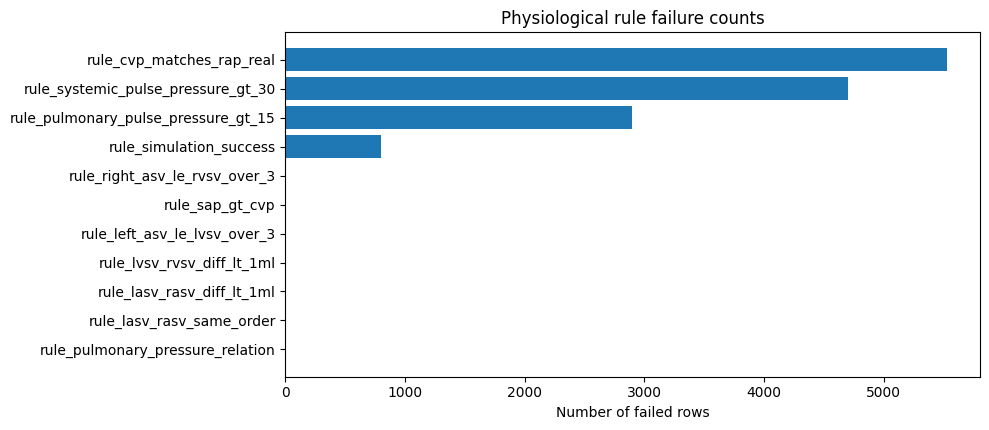

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\rule_failure_counts.png


In [12]:
# ============================================================
# PLOTS: RULE FAILURE COUNTS
# ============================================================

plot_df = rule_summary_df.sort_values("n_fail", ascending=True)

plt.figure(figsize=(10, max(4, 0.4 * len(plot_df))))
plt.barh(plot_df["rule"], plot_df["n_fail"])
plt.xlabel("Number of failed rows")
plt.title("Physiological rule failure counts")
plt.tight_layout()

plot_path = ANALYSIS_DIR / "rule_failure_counts.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print("Saved:", plot_path)

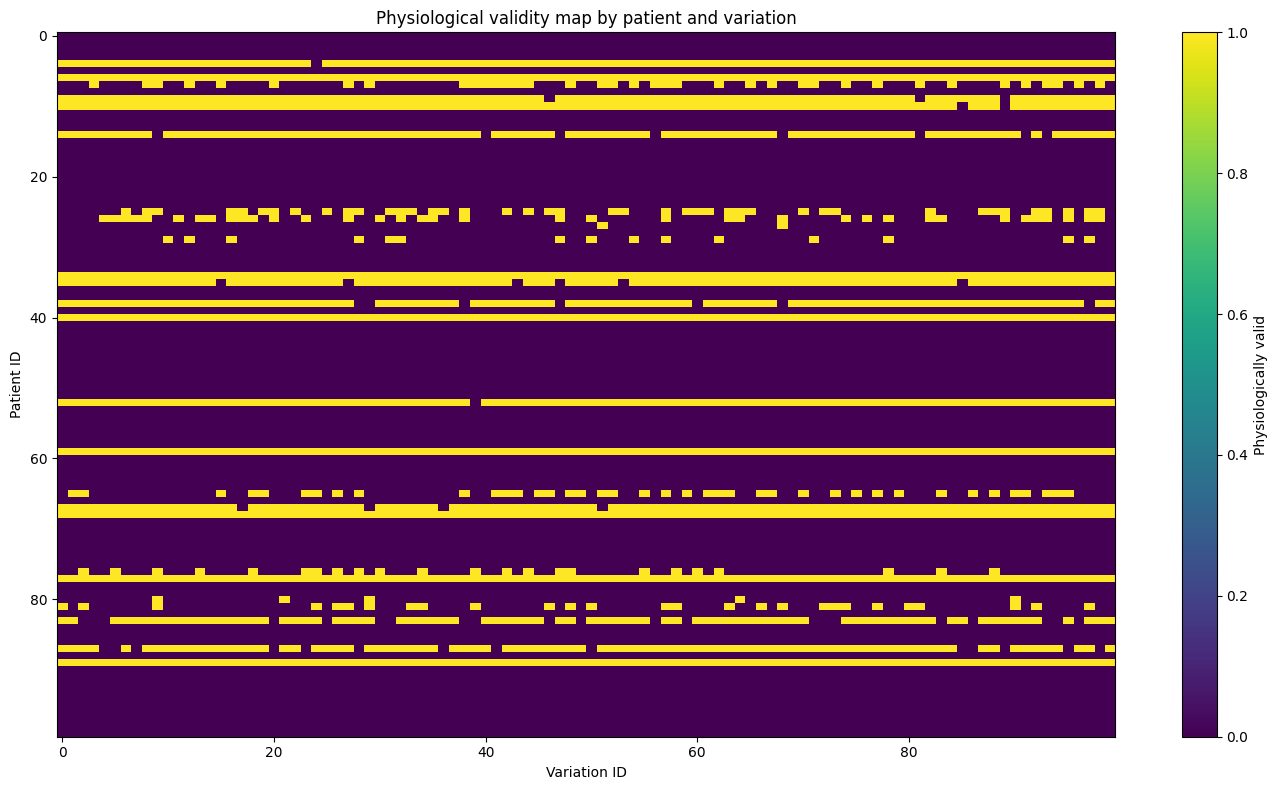

Saved: c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity\validity_map_patient_variation.png


In [13]:
# ============================================================
# PLOTS: VALIDITY MAP BY PATIENT AND VARIATION
# ============================================================

if has_cols(analysis_df, ["patient_id", "variation_id"]):
    validity_map = (
        analysis_df
        .pivot_table(
            index="patient_id",
            columns="variation_id",
            values="is_physiologically_valid",
            aggfunc="mean"
        )
        .sort_index()
        .fillna(0)
    )

    plt.figure(figsize=(14, 8))
    plt.imshow(validity_map.values, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Physiologically valid")
    plt.xlabel("Variation ID")
    plt.ylabel("Patient ID")
    plt.title("Physiological validity map by patient and variation")
    plt.tight_layout()

    plot_path = ANALYSIS_DIR / "validity_map_patient_variation.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()

    print("Saved:", plot_path)
else:
    print("patient_id or variation_id missing; skipping validity map.")

In [14]:
# ============================================================
# OPTIONAL: BASIC ML-READY COLUMN SPLIT
# ============================================================

output_cols = [
    "LAP_real", "RAP_real",
    "SAP_real", "DAP_real",
    "sPAP_real", "dPAP_real",
    "EDV_LV_real", "ESV_LV_real",
    "EDV_RV_real", "ESV_RV_real",
    "CO_real",
]

excluded_input_cols = [
    "campaign_name",
    "sampling_method",
    "simulation_status",
    "error_message",
]

available_output_cols = [c for c in output_cols if c in valid_clean_df.columns]

candidate_input_cols = [
    c for c in valid_clean_df.columns
    if c not in available_output_cols
    and c not in excluded_input_cols
]

print("Available output columns:")
print(available_output_cols)

print("\nCandidate input columns:")
print(candidate_input_cols)

X_preview = valid_clean_df[candidate_input_cols].copy()
y_preview = valid_clean_df[available_output_cols].copy()

print("\nX preview shape:", X_preview.shape)
print("y preview shape:", y_preview.shape)

display(X_preview.head())
display(y_preview.head())

Available output columns:
['LAP_real', 'RAP_real', 'SAP_real', 'DAP_real', 'sPAP_real', 'dPAP_real', 'EDV_LV_real', 'ESV_LV_real', 'EDV_RV_real', 'ESV_RV_real', 'CO_real']

Candidate input columns:
['simulation_id', 'patient_id', 'variation_id', 'random_seed', 'EDVLV', 'ESVLV', 'LVSV', 'LVEF', 'EDVRV', 'ESVRV', 'RVSV', 'RVEF', 'hr', 'COLV', 'SVR', 'PVR', 'CVP', 'LAP', 'MAP', 'SAP', 'DAP', 'mPAP', 'sPAP', 'dPAP', 'weight', 'Rsysven', 'mcfp', 'graft_length', 'BSA', 'k_Vtot', 'k_Vsys', 'k_Vusv_sys', 'k_Vusv_sys_ven', 'k_Vusv_pulm_ven', 'k_Ctot', 'k_Csys', 'k_Rsysven', 'k_Rpulmart', 'k_ESP_LV', 'k_ESP_RV']

X preview shape: (1861, 40)
y preview shape: (1861, 11)


,simulation_id,patient_id,variation_id,random_seed,EDVLV,ESVLV,LVSV,LVEF,EDVRV,ESVRV,RVSV,RVEF,hr,COLV,SVR,PVR,CVP,LAP,MAP,SAP,DAP,mPAP,sPAP,dPAP,weight,Rsysven,mcfp,graft_length,BSA,k_Vtot,k_Vsys,k_Vusv_sys,k_Vusv_sys_ven,k_Vusv_pulm_ven,k_Ctot,k_Csys,k_Rsysven,k_Rpulmart,k_ESP_LV,k_ESP_RV
400,401,5,1,42,94.889282,84.367466,10.521816,11.088519,16.733396,6.21158,10.521816,62.879145,107,1125.834322,1.960804,0.344639,15.774264,24.674671,52.566607,75.495713,41.102054,31.14145,39.14145,23.14145,16.531706,0.138478,18.372652,0.140842,7.454187,60.382483,0.891234,0.850228,0.965001,0.874338,2.069801,0.797364,0.052013,0.706299,0.957860,0.994115
401,402,5,2,42,94.889282,84.367466,10.521816,11.088519,16.733396,6.21158,10.521816,62.879145,107,1125.834322,1.960804,0.344639,15.774264,24.674671,52.566607,75.495713,41.102054,31.14145,39.14145,23.14145,16.531706,0.138478,18.372652,0.140842,7.454187,82.001397,0.777128,0.869327,0.933856,0.852157,2.308201,0.888577,0.058408,0.602916,0.943540,0.954784
402,403,5,3,42,94.889282,84.367466,10.521816,11.088519,16.733396,6.21158,10.521816,62.879145,107,1125.834322,1.960804,0.344639,15.774264,24.674671,52.566607,75.495713,41.102054,31.14145,39.14145,23.14145,16.531706,0.138478,18.372652,0.140842,7.454187,79.829615,0.764084,0.867082,0.903241,0.939338,2.531213,0.879871,0.053859,0.708780,1.001923,0.953648
403,404,5,4,42,94.889282,84.367466,10.521816,11.088519,16.733396,6.21158,10.521816,62.879145,107,1125.834322,1.960804,0.344639,15.774264,24.674671,52.566607,75.495713,41.102054,31.14145,39.14145,23.14145,16.531706,0.138478,18.372652,0.140842,7.454187,77.271829,0.866768,0.893458,0.918928,0.926574,2.189193,0.878913,0.060429,0.762656,1.023625,0.963804
404,405,5,5,42,94.889282,84.367466,10.521816,11.088519,16.733396,6.21158,10.521816,62.879145,107,1125.834322,1.960804,0.344639,15.774264,24.674671,52.566607,75.495713,41.102054,31.14145,39.14145,23.14145,16.531706,0.138478,18.372652,0.140842,7.454187,71.082054,0.863869,0.783735,0.955406,0.823193,1.885917,0.846059,0.049863,0.521090,0.966918,0.998769


,LAP_real,RAP_real,SAP_real,DAP_real,sPAP_real,dPAP_real,EDV_LV_real,ESV_LV_real,EDV_RV_real,ESV_RV_real,CO_real
400,21.571105,15.180084,70.238792,41.879235,36.097144,21.567842,94.203006,81.259237,17.558543,5.072654,1.264065
401,22.627834,15.496620,69.897577,41.838604,36.539449,22.870116,94.885382,82.026056,17.625662,5.353381,1.249908
402,20.519453,15.776470,72.351291,43.146774,35.036327,20.676385,93.243404,80.214311,17.723789,5.201945,1.296734
403,20.019485,15.857842,73.228319,43.637098,34.816955,20.037005,92.653596,79.623452,17.746126,5.168877,1.315100
404,22.001594,15.119894,70.956567,42.173869,35.890620,22.854131,94.432043,81.287964,17.532915,4.930452,1.282990


In [15]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 100)
print("07F PHYSIOLOGICAL VALIDITY FILTER SUMMARY")
print("=" * 100)

print(f"Full dataset rows: {len(analysis_df):,}")
print(f"Valid rows: {len(valid_df):,}")
print(f"Invalid rows: {len(invalid_df):,}")
print(f"Validity rate: {len(valid_df) / len(analysis_df):.2%}")

print("\nSimulation status counts:")
display(analysis_df["simulation_status"].value_counts(dropna=False))

print("\nRule failure summary:")
display(rule_summary_df)

print("\nPatient-level worst validity rates:")
display(patient_validity_summary.head(15))

print("\nSaved files in:")
print(ANALYSIS_DIR)

07F PHYSIOLOGICAL VALIDITY FILTER SUMMARY
Full dataset rows: 10,000
Valid rows: 1,861
Invalid rows: 8,139
Validity rate: 18.61%

Simulation status counts:


simulation_status
success    9200
failed      800
Name: count, dtype: int64


Rule failure summary:


,rule,n_pass,n_fail,failure_rate
0,rule_cvp_matches_rap_real,4471,5529,0.5529
1,rule_systemic_pulse_pressure_gt_30,5300,4700,0.4700
2,rule_pulmonary_pulse_pressure_gt_15,7100,2900,0.2900
3,rule_simulation_success,9200,800,0.0800
4,rule_lvsv_rvsv_diff_lt_1ml,10000,0,0.0000
5,rule_lasv_rasv_diff_lt_1ml,10000,0,0.0000
6,rule_lasv_rasv_same_order,10000,0,0.0000
7,rule_pulmonary_pressure_relation,10000,0,0.0000
8,rule_right_asv_le_rvsv_over_3,10000,0,0.0000
9,rule_left_asv_le_lvsv_over_3,10000,0,0.0000



Patient-level worst validity rates:


,patient_id,total_sims,successful_sims,failed_sims,valid_sims,invalid_sims,validity_rate
8,9,100,0,100,0,100,0.0
22,23,100,0,100,0,100,0.0
23,24,100,0,100,0,100,0.0
48,49,100,0,100,0,100,0.0
50,51,100,0,100,0,100,0.0
62,63,100,0,100,0,100,0.0
84,85,100,0,100,0,100,0.0
98,99,100,0,100,0,100,0.0
0,1,100,100,0,0,100,0.0
1,2,100,100,0,0,100,0.0



Saved files in:
c:\Users\Maxim\Documents\02_ESILV\A4\Stage\03_Models\DIA\Main_project\01_Data\Conditional_Sampling\simulation_results\conditional_sampling_100_patients_100_variations_v1\analysis_07F_physiological_validity
